# Base 5 — ouro semanal

In [10]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

def find_project_root(start):
    for candidate in (start, *start.parents):
        if (candidate / 'config' / 'projeto.yaml').is_file():
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')

ROOT = find_project_root(Path.cwd().resolve())
sys.path.insert(0, str(ROOT / 'src'))
from series_temporais.data.preparacao_base5 import construir_quadro_ouro, preparar_ouro_semanal
from series_temporais.validation.temporal_split import purged_time_series_splits

BASE_DIR = ROOT / 'trabalho/bases/grupo5'
DATA_PATH = BASE_DIR / 'grupo5.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = .75
RANDOM_STATE = 42
REFIT_EVERY = 26
TARGET = 'target_log_return_t_plus_1'
np.random.seed(RANDOM_STATE)

## 1. Revisão da documentação e do dicionário de externas

A revisão confirma que `TREASURY_10Y` e `FED_FUNDS_RATE` só podem entrar com
valores conhecidos até a origem semanal. Fonte primária, unidade, convenção e
horário de publicação continuam pendentes; essa limitação não é escondida.

In [11]:
review_paths = {
    'documentação': BASE_DIR / 'documentacao_base5.md',
    'dicionário de externas': BASE_DIR / 'dicionario_variaveis_externas_base5.md',
    'ADR do experimento': ROOT / 'docs/adr/005-base5-random-forest-semanal.md',
    'CSV atual': DATA_PATH,
}
review = pd.DataFrame({
    'artefato': review_paths.keys(),
    'caminho': [str(path.relative_to(ROOT)) for path in review_paths.values()],
    'existe': [path.exists() for path in review_paths.values()],
})
assert review.existe.all(), review.loc[~review.existe]
display(review)
print('Pendências: fonte/unidade das séries e aprovação das origens comuns aos quatro modelos.')

,artefato,caminho,existe
0,documentação,trabalho\bases\grupo5\documentacao_base5.md,True
1,dicionário de externas,trabalho\bases\grupo5\dicionario_variaveis_ext...,True
2,ADR do experimento,docs\adr\005-base5-random-forest-semanal.md,True
3,CSV atual,trabalho\bases\grupo5\grupo5.csv,True


Pendências: fonte/unidade das séries e aprovação das origens comuns aos quatro modelos.


## 2. Ingestão e auditoria do CSV atual

Somente `DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a
reconstrução. As derivações entregues são auditadas, mas excluídas do modelo,
pois foram calculadas em outra grade temporal.

In [12]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
derived_source_columns = expected_columns[4:]
df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='raise')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)
next_row_match = np.isclose(df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False).mean()
lag_1_match = np.isclose(df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'primeira_data': df.DATE.min(), 'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_shift_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.is_unique and df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())

,valor
arquivo,trabalho\bases\grupo5\grupo5.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
valores_nulos,0
precos_nao_positivos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 3. Limpeza e preparação semanal causal

Cada sexta-feira representa a origem semanal. Em semanas vazias, somente o
último estado já conhecido é carregado para frente; data da última cotação,
idade e indicador de carregamento permanecem explícitos.

In [13]:
weekly = preparar_ouro_semanal(df, WEEKLY_RULE)
weekly_quality = pd.Series({
    'semanas': len(weekly), 'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(), 'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
display(weekly_quality)
display(weekly.head())

,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,weeks_without_observation,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,0,0,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,0,1,0,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,0,0,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,0,0,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,0,1,0,3.731699,0.000000


## 4. Gráficos exploratórios

Os gráficos preservam picos e tornam visíveis retorno, taxas, volatilidade e
cobertura. Nenhuma observação é removida por parecer extrema.

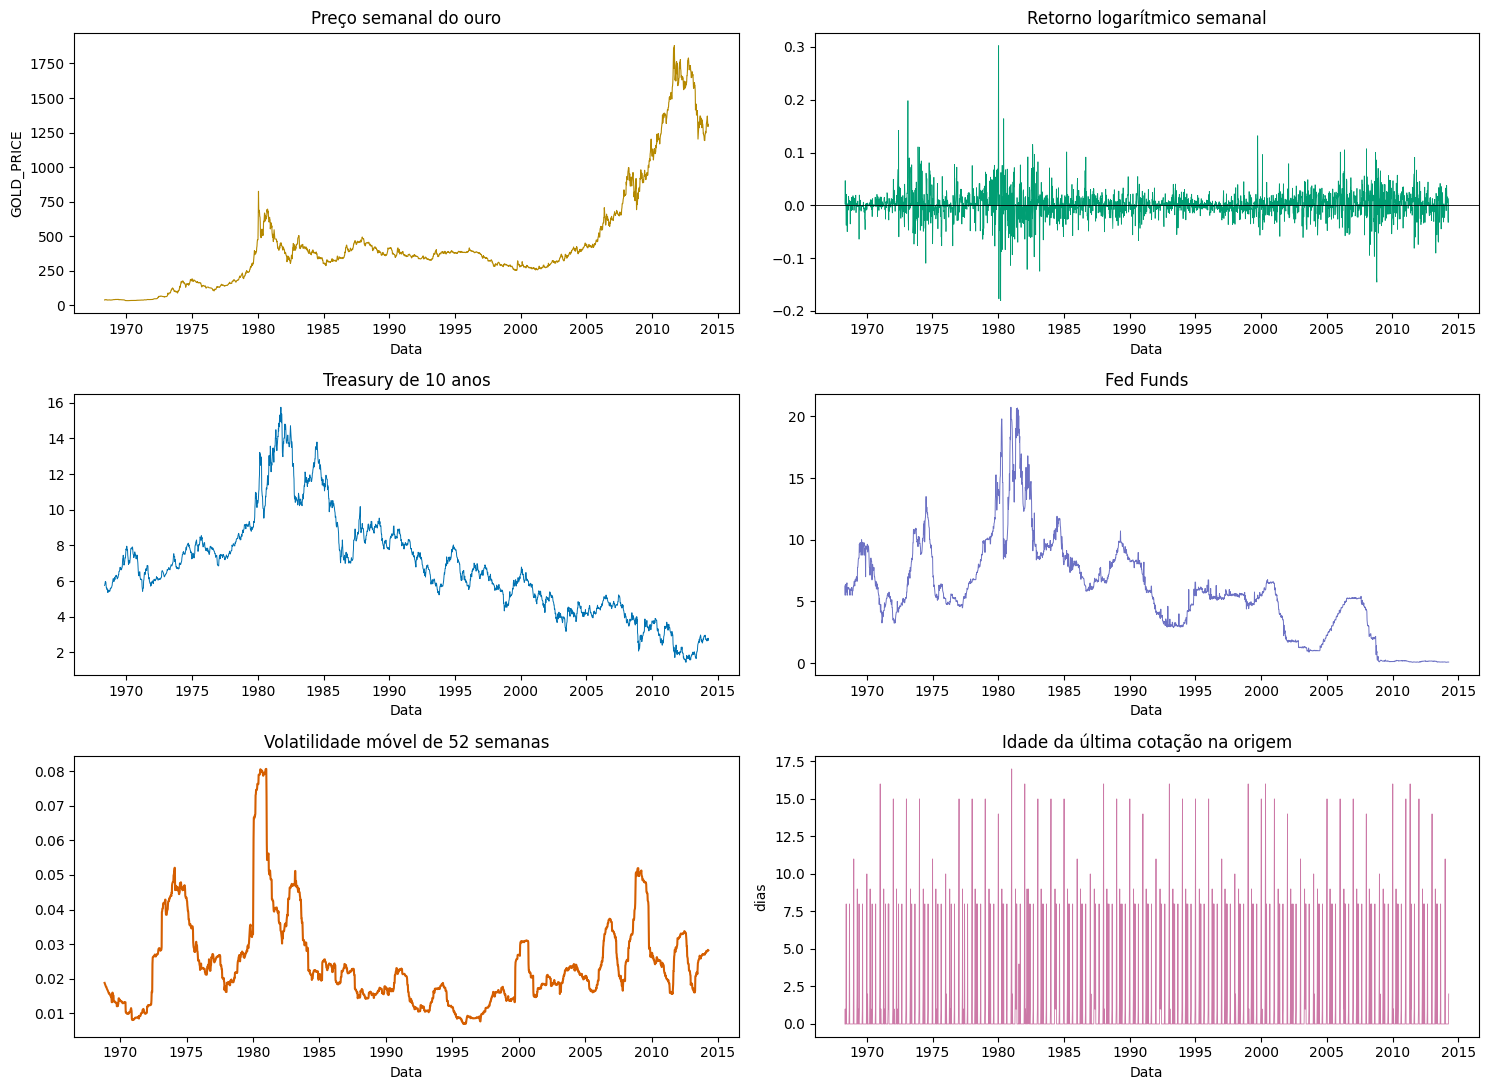

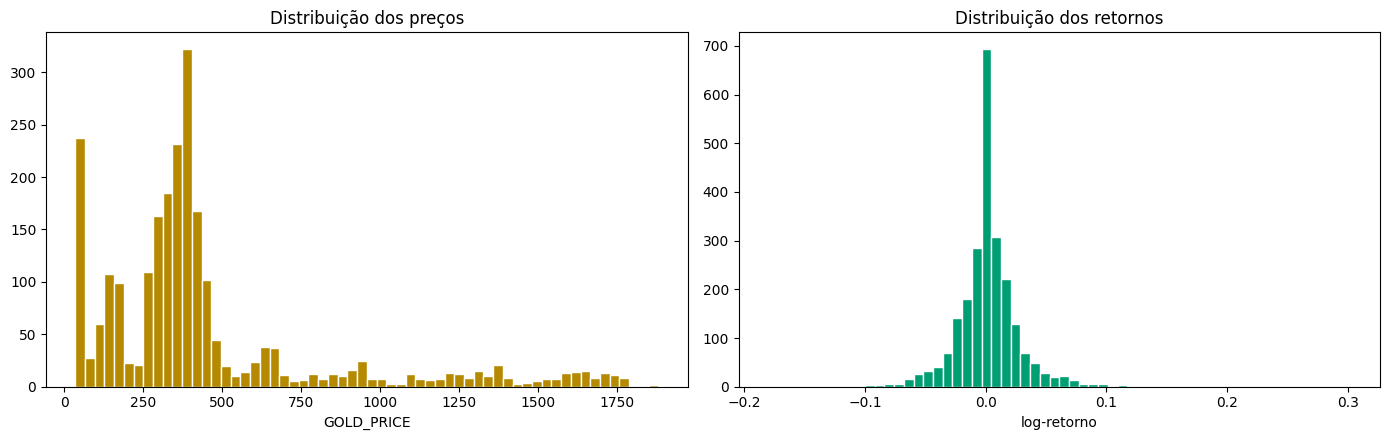

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#009e73')
axes[0, 1].axhline(0, color='black', lw=.6); axes[0, 1].set(title='Retorno logarítmico semanal')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#0072b2')
axes[1, 0].set(title='Treasury de 10 anos')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds')
axes[2, 0].plot(weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(), color='#d55e00')
axes[2, 0].set(title='Volatilidade móvel de 52 semanas')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cc79a7')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat: ax.set_xlabel('Data')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#009e73')
axes[1].set(title='Distribuição dos retornos', xlabel='log-retorno')
plt.tight_layout(); plt.show()

## 5. STL e força da sazonalidade

A STL robusta usa apenas os 75% iniciais da série semanal. A força sazonal é
`max(0, 1 - Var(R) / Var(S + R))`; a força da tendência usa fórmula análoga.

,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendência,0.927517,52


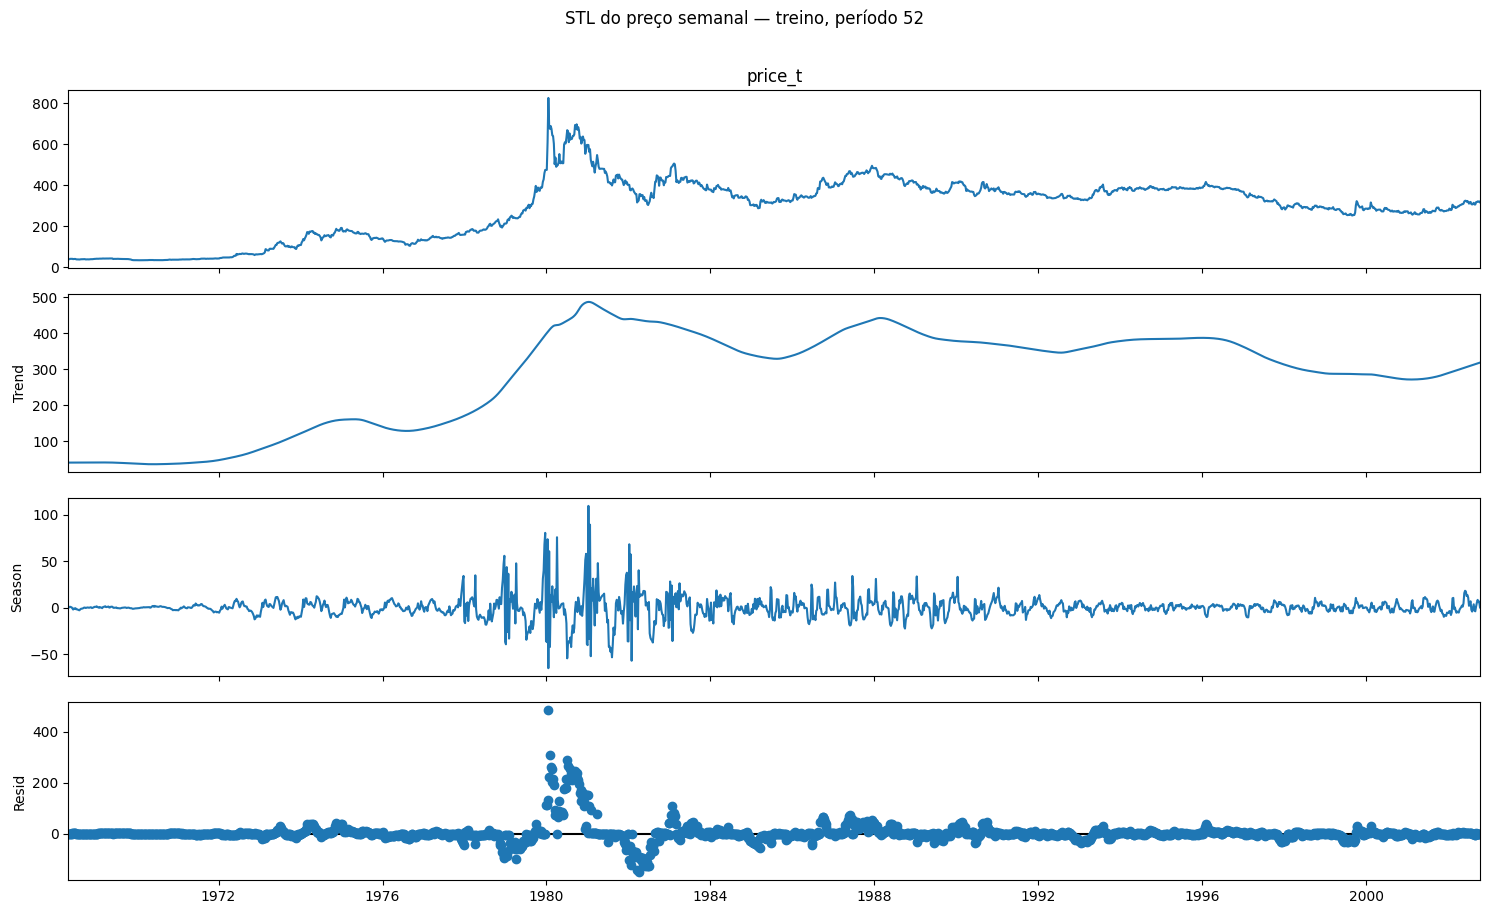

Interpretação: força sazonal 0.000 e força de tendência 0.928. A tendência apresenta crescimento líquido de 277.43 unidades no treino. O resíduo concentra variação não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.


In [15]:
stl_cut = int(len(weekly) * TRAIN_RATIO)
stl_series = weekly.iloc[:stl_cut].set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
resid_var = np.var(stl_result.resid, ddof=1)
seasonal_strength = max(0., 1. - resid_var / np.var(stl_result.seasonal + stl_result.resid, ddof=1))
trend_strength = max(0., 1. - resid_var / np.var(stl_result.trend + stl_result.resid, ddof=1))
display(pd.DataFrame({
    'componente': ['sazonalidade', 'tendência'],
    'forca': [seasonal_strength, trend_strength], 'periodo_stl': STL_PERIOD,
}))
fig = stl_result.plot(); fig.set_size_inches(15, 9)
fig.suptitle('STL do preço semanal — treino, período 52', y=1.01)
plt.tight_layout(); plt.show()
trend_change = float(stl_result.trend.iloc[-1] - stl_result.trend.iloc[0])
trend_direction = 'crescimento' if trend_change > 0 else 'queda' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: força sazonal {seasonal_strength:.3f} e força de tendência '
    f'{trend_strength:.3f}. A tendência apresenta {trend_direction} líquido de '
    f'{abs(trend_change):.2f} unidades no treino. O resíduo concentra variação '
    'não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.'
)

## 6. Features, corte temporal, ADF, ACF e PACF

Lags e janelas são reconstruídos depois da agregação semanal. Datas-alvo,
preço futuro e todas as derivações entregues no CSV ficam fora de `X`.

,recorte,linhas,inicio_origem,fim_origem
0,treino,1757,1969-05-09,2003-01-03
1,teste,586,2003-01-17,2014-04-04


,serie,estatistica,p_valor,lags
0,log do preço semanal — treino,-2.511253,1.127602e-01,8
1,retorno log semanal — treino,-14.203771,1.769288e-26,7


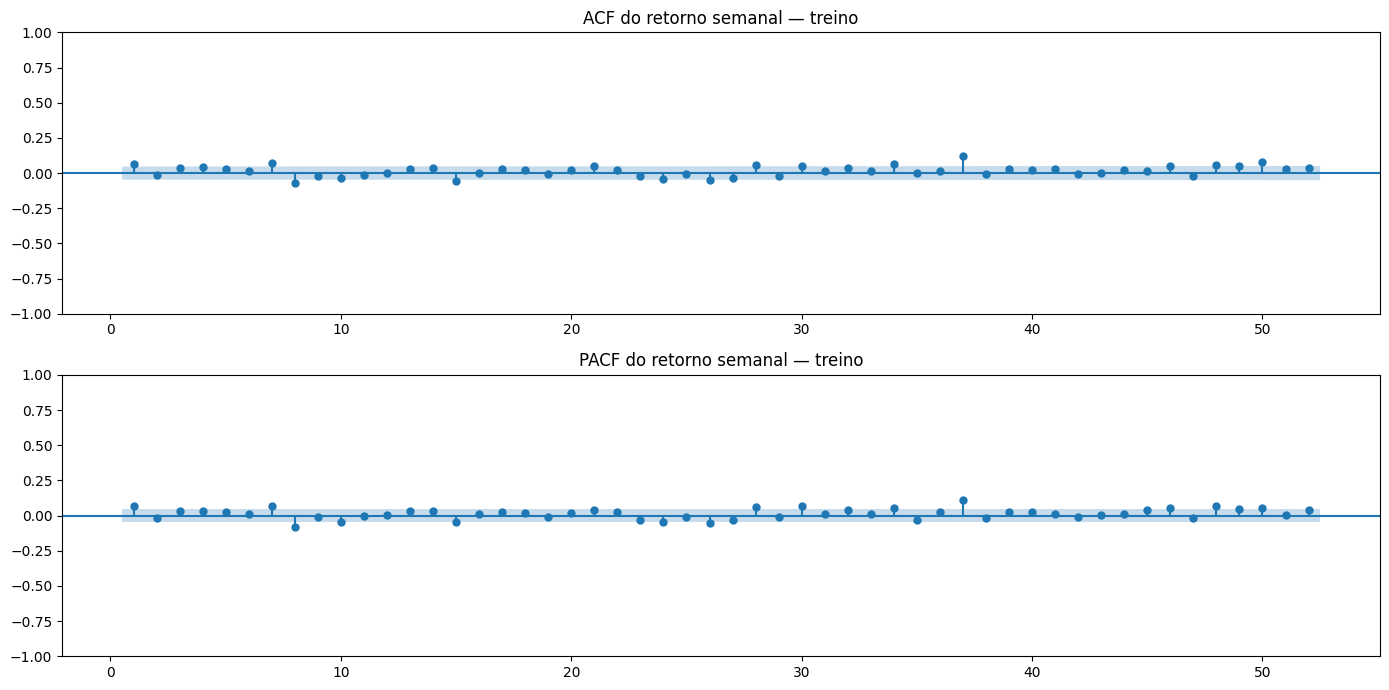

In [16]:
model_df, feature_columns = construir_quadro_ouro(weekly)
split_index = int(len(model_df) * TRAIN_RATIO)
first_test_origin = model_df.iloc[split_index].DATE
train_df = model_df.iloc[:split_index].loc[lambda x: x.target_date < first_test_origin].reset_index(drop=True)
test_df = model_df.iloc[split_index:].reset_index(drop=True)
X_train, y_train = train_df[feature_columns], train_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]
assert train_df.target_date.max() < test_df.DATE.min()
assert not set(derived_source_columns).intersection(feature_columns)

def adf_row(name, series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'serie': name, 'estatistica': result[0], 'p_valor': result[1], 'lags': result[2]}
display(pd.DataFrame({
    'recorte': ['treino', 'teste'], 'linhas': [len(train_df), len(test_df)],
    'inicio_origem': [train_df.DATE.min(), test_df.DATE.min()],
    'fim_origem': [train_df.DATE.max(), test_df.DATE.max()],
}))
display(pd.DataFrame([
    adf_row('log do preço semanal — treino', train_df.log_price_t),
    adf_row('retorno log semanal — treino', train_df.log_return_t),
]))
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_df.log_return_t, lags=52, zero=False, ax=axes[0])
plot_pacf(train_df.log_return_t, lags=52, zero=False, method='ywm', ax=axes[1])
axes[0].set_title('ACF do retorno semanal — treino')
axes[1].set_title('PACF do retorno semanal — treino')
plt.tight_layout(); plt.show()

## 7. Otimização temporal do Random Forest

O desenho investiga explicitamente `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf` e `max_features` em três dobras
expansivas purgadas. O teste final não participa da seleção.

In [17]:
candidates = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': .7},
]
cv_splits = purged_time_series_splits(train_df.DATE, train_df.target_date, n_splits=3)
search_rows = []
search_start = time.perf_counter()
for candidate_id, params in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        candidate = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        fold_start = time.perf_counter()
        candidate.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        prediction = candidate.predict(X_train.iloc[validation_idx])
        fold_seconds.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(y_train.iloc[validation_idx], prediction))
    search_rows.append({
        'candidate_id': candidate_id, **params,
        'mean_validation_mae': np.mean(fold_maes),
        'std_validation_mae': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_seconds),
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae', 'std_validation_mae', 'candidate_id']
).reset_index(drop=True)
best_params = {key: search_results.iloc[0][key] for key in candidates[0]}
for key in ('n_estimators', 'min_samples_split', 'min_samples_leaf'):
    best_params[key] = int(best_params[key])
best_params['max_depth'] = None if pd.isna(best_params['max_depth']) else int(best_params['max_depth'])
display(search_results)
print('Melhores parâmetros:', best_params)
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_validation_mae,std_validation_mae,fit_seconds
0,6,250,6.0,2,3,sqrt,0.017681,0.009973,7.412052
1,3,100,6.0,2,1,sqrt,0.018391,0.011065,3.156248
2,8,250,6.0,10,3,0.7,0.018521,0.010608,10.185213
3,5,100,NaN,2,3,sqrt,0.018736,0.009472,3.274637
4,4,100,12.0,10,1,sqrt,0.019229,0.010529,3.116975
5,9,250,12.0,5,2,0.7,0.019705,0.011922,14.067886
6,1,100,NaN,2,1,sqrt,0.019980,0.010728,4.842249
7,2,250,NaN,2,1,sqrt,0.020055,0.010943,10.121212
8,7,100,NaN,2,1,0.7,0.021400,0.011445,11.073454


Melhores parâmetros: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Tempo de busca: 67.63 s


## 8. Walk-forward final e importância das features

Os parâmetros permanecem fixos. O modelo é reajustado a cada 26 semanas por
limitação computacional; cada origem ainda recebe previsão fora da amostra.
O ajuste só recebe alvos estritamente anteriores à nova origem. A periodicidade
é provisória e deverá ser igualada aos demais modelos no protocolo final.

,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,y_pred_return_rf,model_refit_origin,training_target_cutoff,y_pred_return_zero,price_pred_rf,price_pred_persistence,residual_return_rf,residual_price_rf,absolute_error_price_rf
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,0.001560,2003-01-17,2003-01-10,0.0,358.759251,358.20,0.014777,5.340749,5.340749
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,0.001796,2003-01-17,2003-01-10,0.0,364.754473,364.10,0.015224,5.595527,5.595527
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,0.001617,2003-01-17,2003-01-10,0.0,370.949372,370.35,-0.001077,-0.399372,0.399372
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,0.000988,2003-01-17,2003-01-10,0.0,370.916141,370.55,-0.040343,-14.666141,14.666141
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,0.000830,2003-01-17,2003-01-10,0.0,356.545873,356.25,-0.007166,-2.545873,2.545873


,feature,importance_mean,importance_std,grupo
0,log_return_t,0.062582,0.007563,historico_ou_cobertura
1,return_lag_26,0.042095,0.008139,historico_ou_cobertura
2,return_vol_13,0.040080,0.002387,historico_ou_cobertura
3,return_lag_4,0.037043,0.006448,historico_ou_cobertura
4,price_std_13,0.035883,0.002126,historico_ou_cobertura
5,price_std_26,0.032504,0.004702,historico_ou_cobertura
6,return_lag_13,0.031849,0.003580,historico_ou_cobertura
7,return_lag_2,0.031788,0.002988,historico_ou_cobertura
8,return_vol_26,0.027380,0.003358,historico_ou_cobertura
9,return_lag_1,0.027082,0.005831,historico_ou_cobertura


,grupo,importance_mean
0,calendario,0.058959
1,externa_na_origem,0.175339
2,historico_ou_cobertura,0.765702


Externas mais importantes (importância nativa, não causal):


,feature,importance_mean,importance_std,grupo
10,fed_funds_lag_4,0.026724,0.001768,externa_na_origem
21,fed_funds_rate_t,0.020866,0.004975,externa_na_origem
23,fed_funds_lag_13,0.018471,0.003653,externa_na_origem
25,fed_funds_change_t,0.018047,0.002910,externa_na_origem
26,fed_funds_lag_1,0.017414,0.002752,externa_na_origem
27,treasury_change_t,0.017303,0.002516,externa_na_origem
33,treasury_lag_4,0.015269,0.002016,externa_na_origem
35,treasury_10y_t,0.014679,0.003152,externa_na_origem


Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; nenhuma taxa observada da semana-alvo entra em X.


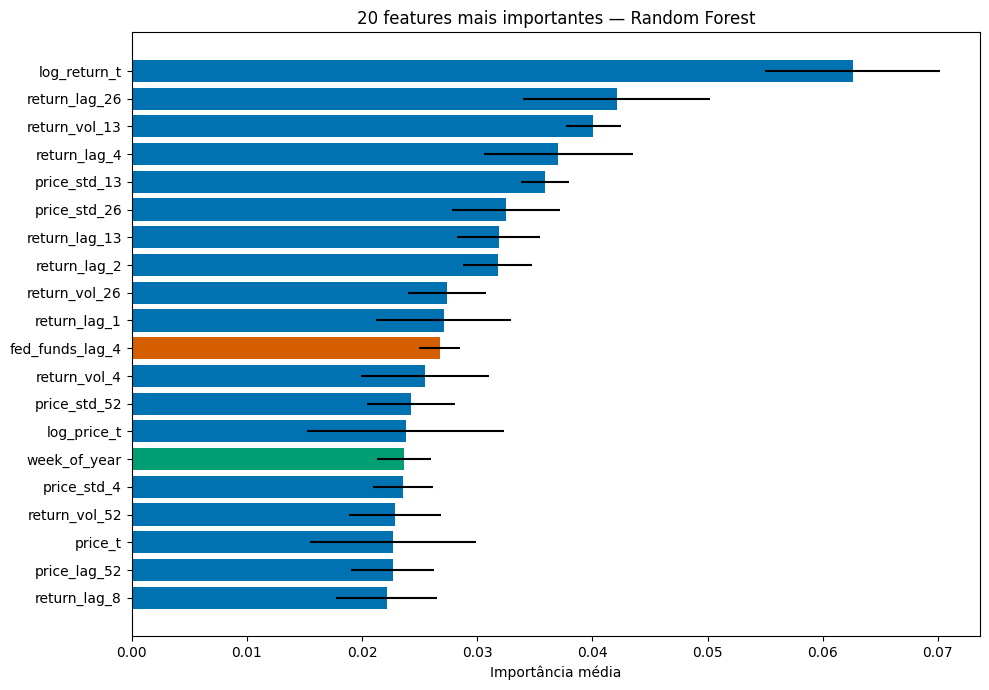

In [18]:
prediction_values, prediction_refits, training_cutoffs = [], [], []
fit_rows, importance_rows = [], []
evaluation_start = time.perf_counter()
for block_start in range(0, len(test_df), REFIT_EVERY):
    block_end = min(block_start + REFIT_EVERY, len(test_df))
    current_origin = test_df.iloc[block_start].DATE
    known_test = test_df.target_date < current_origin
    history = pd.concat([train_df, test_df.loc[known_test]], ignore_index=True)
    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    fit_start = time.perf_counter()
    model.fit(history[feature_columns], history[TARGET])
    prediction_values.extend(model.predict(X_test.iloc[block_start:block_end]))
    prediction_refits.extend([current_origin] * (block_end - block_start))
    training_cutoff = history.target_date.max()
    training_cutoffs.extend([training_cutoff] * (block_end - block_start))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_treino': len(history),
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'fit_seconds': time.perf_counter() - fit_start,
    })
    importance_rows.append(model.feature_importances_)
evaluation_seconds = time.perf_counter() - evaluation_start
predictions = test_df[['DATE', 'target_date', 'price_t', 'target_price_t_plus_1', TARGET, 'target_has_new_quote']].copy()
predictions = predictions.rename(columns={TARGET: 'y_true_return'})
predictions['y_pred_return_rf'] = np.asarray(prediction_values)
predictions['model_refit_origin'] = prediction_refits
predictions['training_target_cutoff'] = training_cutoffs
assert (predictions.training_target_cutoff < predictions.DATE).all()
predictions['y_pred_return_zero'] = 0.
predictions['price_pred_rf'] = predictions.price_t * np.exp(predictions.y_pred_return_rf)
predictions['price_pred_persistence'] = predictions.price_t
predictions['residual_return_rf'] = predictions.y_true_return - predictions.y_pred_return_rf
predictions['residual_price_rf'] = predictions.target_price_t_plus_1 - predictions.price_pred_rf
predictions['absolute_error_price_rf'] = predictions.residual_price_rf.abs()
fit_log = pd.DataFrame(fit_rows)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': np.mean(importance_rows, axis=0),
    'importance_std': np.std(importance_rows, axis=0),
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
external_prefixes = ('treasury_', 'fed_funds_')
feature_importance['grupo'] = np.select(
    [feature_importance.feature.str.startswith(external_prefixes),
     feature_importance.feature.str.startswith(('price_', 'return_', 'log_', 'source_', 'quote_', 'weeks_'))],
    ['externa_na_origem', 'historico_ou_cobertura'], default='calendario',
)
display(predictions.head())
display(feature_importance.head(20))
display(feature_importance.groupby('grupo', as_index=False).importance_mean.sum())
print('Externas mais importantes (importância nativa, não causal):')
display(feature_importance.loc[feature_importance.grupo.eq('externa_na_origem')].head(8))
print(
    'Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; '
    'nenhuma taxa observada da semana-alvo entra em X.'
)
fig, ax = plt.subplots(figsize=(10, 7))
top = feature_importance.head(20).sort_values('importance_mean')
palette = {'externa_na_origem': '#d55e00', 'historico_ou_cobertura': '#0072b2', 'calendario': '#009e73'}
ax.barh(top.feature, top.importance_mean, xerr=top.importance_std,
        color=top.grupo.map(palette))
ax.set(title='20 features mais importantes — Random Forest', xlabel='Importância média')
plt.tight_layout(); plt.show()

## 9. MAE e demais métricas

In [19]:
def metric_row(name, return_prediction, price_prediction, subset=None):
    mask = pd.Series(True, index=predictions.index) if subset is None else subset
    actual_return = predictions.loc[mask, 'y_true_return']
    predicted_return = np.asarray(return_prediction)[mask.to_numpy()]
    actual_price = predictions.loc[mask, 'target_price_t_plus_1']
    predicted_price = np.asarray(price_prediction)[mask.to_numpy()]
    return {
        'modelo': name, 'observacoes': int(mask.sum()),
        'MAE_retorno': mean_absolute_error(actual_return, predicted_return),
        'RMSE_retorno': mean_squared_error(actual_return, predicted_return) ** .5,
        'MedAE_retorno': median_absolute_error(actual_return, predicted_return),
        'R2_retorno': r2_score(actual_return, predicted_return),
        'vies_retorno': np.mean(actual_return - predicted_return),
        'acuracia_direcional': np.mean(np.sign(actual_return) == np.sign(predicted_return)),
        'MAE_preco': mean_absolute_error(actual_price, predicted_price),
    }
new_quote = predictions.target_has_new_quote.eq(1)
metrics = pd.DataFrame([
    metric_row('Random Forest — todas', predictions.y_pred_return_rf, predictions.price_pred_rf),
    metric_row('Persistência — todas', predictions.y_pred_return_zero, predictions.price_pred_persistence),
    metric_row('Random Forest — nova cotação', predictions.y_pred_return_rf, predictions.price_pred_rf, new_quote),
    metric_row('Persistência — nova cotação', predictions.y_pred_return_zero, predictions.price_pred_persistence, new_quote),
])
rf_mae = metrics.loc[metrics.modelo.eq('Random Forest — todas'), 'MAE_preco'].iloc[0]
baseline_mae = metrics.loc[metrics.modelo.eq('Persistência — todas'), 'MAE_preco'].iloc[0]
metrics['skill_mae_preco_vs_persistencia'] = 1 - metrics.MAE_preco / baseline_mae
display(metrics)

,modelo,observacoes,MAE_retorno,RMSE_retorno,MedAE_retorno,R2_retorno,vies_retorno,acuracia_direcional,MAE_preco,skill_mae_preco_vs_persistencia
0,Random Forest — todas,586,0.021467,0.029660,0.016777,-0.094699,0.005345,0.462457,20.035629,-0.057180
1,Persistência — todas,586,0.020101,0.028434,0.016044,-0.006091,0.002212,0.109215,18.951962,0.000000
2,Random Forest — nova cotação,523,0.023449,0.031277,0.018899,-0.087223,0.005550,0.518164,21.901119,-0.155612
3,Persistência — nova cotação,523,0.022522,0.030098,0.018257,-0.006830,0.002479,0.001912,21.234895,-0.120459


## 10. Registro de parâmetros, versões e tempo

O registro reúne hash, configuração, features, parâmetros, versões, tempos e
cada reajuste do teste para reprodução completa.

In [20]:
experiment_record = pd.DataFrame([{
    'base': 'Base 5 — ouro semanal', 'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash, 'frequencia': WEEKLY_RULE,
    'alvo': TARGET, 'horizonte_provisorio': '1 semana',
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino': len(train_df), 'linhas_teste': len(test_df),
    'origem_teste_inicial': test_df.DATE.min(), 'origem_teste_final': test_df.DATE.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 5 — ouro semanal
arquivo,trabalho\bases\grupo5\grupo5.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
frequencia,W-FRI
alvo,target_log_return_t_plus_1
horizonte_provisorio,1 semana
split_treino,0.75
random_state,42
linhas_treino,1757
linhas_teste,586


,origem_refit,linhas_treino,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2003-01-17,1757,0,26,2.394281
1,2003-07-18,1782,26,52,2.176020
2,2004-01-16,1808,52,78,2.139458
3,2004-07-16,1834,78,104,2.204256
4,2005-01-14,1860,104,130,2.404330
5,2005-07-15,1886,130,156,2.942872
6,2006-01-13,1912,156,182,2.938048
7,2006-07-14,1938,182,208,2.643130
8,2007-01-12,1964,208,234,3.144146
9,2007-07-13,1990,234,260,3.032868


## 11. Resíduos individuais

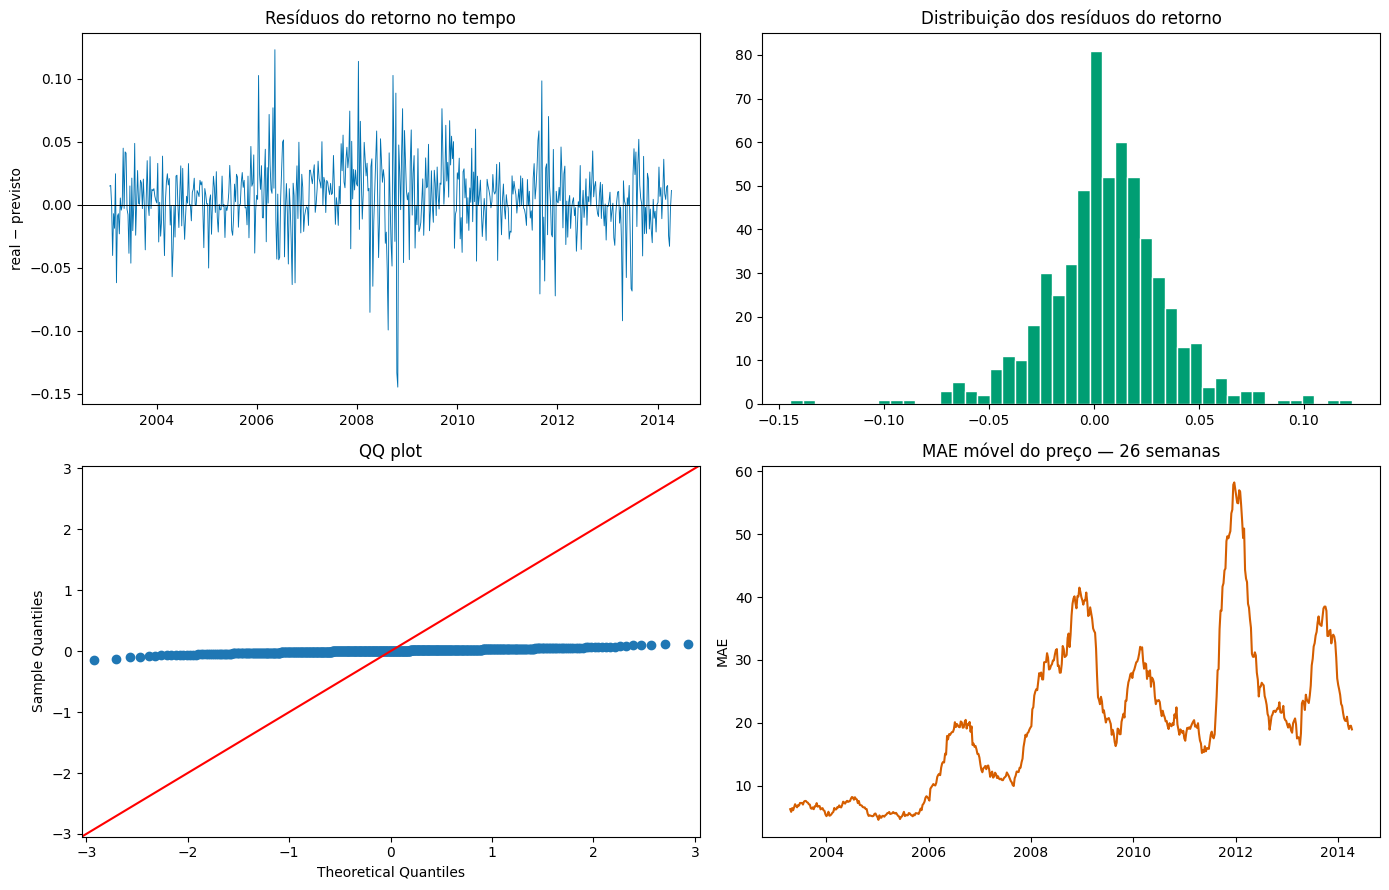

,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,y_pred_return_rf,model_refit_origin,training_target_cutoff,y_pred_return_zero,price_pred_rf,price_pred_persistence,residual_return_rf,residual_price_rf,absolute_error_price_rf
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,0.001560,2003-01-17,2003-01-10,0.0,358.759251,358.20,0.014777,5.340749,5.340749
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,0.001796,2003-01-17,2003-01-10,0.0,364.754473,364.10,0.015224,5.595527,5.595527
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,0.001617,2003-01-17,2003-01-10,0.0,370.949372,370.35,-0.001077,-0.399372,0.399372
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,0.000988,2003-01-17,2003-01-10,0.0,370.916141,370.55,-0.040343,-14.666141,14.666141
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,0.000830,2003-01-17,2003-01-10,0.0,356.545873,356.25,-0.007166,-2.545873,2.545873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,2014-03-07,2014-03-14,1348.25,1370.00,0.016003,1,0.000786,2014-01-03,2013-12-27,0.0,1349.310252,1348.25,0.015217,20.689748,20.689748
582,2014-03-14,2014-03-21,1370.00,1338.50,-0.023261,1,0.001483,2014-01-03,2013-12-27,0.0,1372.033692,1370.00,-0.024745,-33.533692,33.533692
583,2014-03-21,2014-03-28,1338.50,1295.75,-0.032460,1,0.000609,2014-01-03,2013-12-27,0.0,1339.315464,1338.50,-0.033069,-43.565464,43.565464
584,2014-03-28,2014-04-04,1295.75,1293.50,-0.001738,1,0.001181,2014-01-03,2013-12-27,0.0,1297.280794,1295.75,-0.002919,-3.780794,3.780794


In [21]:
residuals = predictions.residual_return_rf
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(predictions.target_date, residuals, lw=.65, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos do retorno no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=45, edgecolor='white', color='#009e73')
axes[0, 1].set(title='Distribuição dos resíduos do retorno')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_rf.rolling(26, min_periods=13).mean(), color='#d55e00')
axes[1, 1].set(title='MAE móvel do preço — 26 semanas', ylabel='MAE')
plt.tight_layout(); plt.show()
display(predictions)

## 12. ACF dos resíduos e Ljung–Box

A ACF e o Ljung–Box verificam se o RF deixou dependência temporal nos erros.
Rejeição a 5% indica que o resíduo não se comporta como ruído branco.

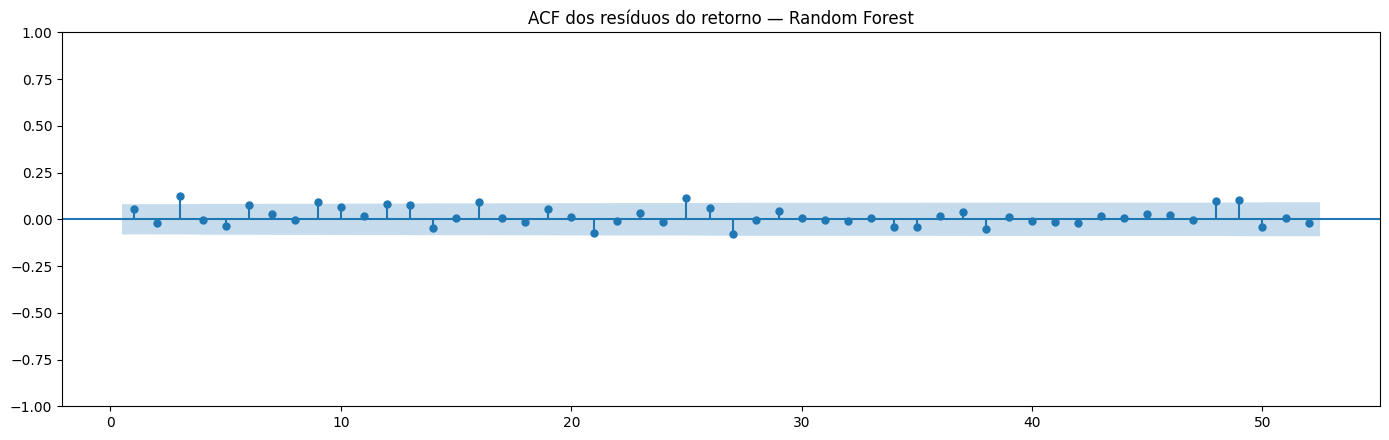

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,1.626592,0.202175,False
4,11.177009,0.024645,True
13,31.150591,0.003205,True
26,54.648778,0.000840,True


In [22]:
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=52, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do retorno — Random Forest')
plt.tight_layout(); plt.show()
ljung_box = acorr_ljungbox(residuals, lags=[1, 4, 13, 26], return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)